Размер датасета: (25000, 62)

Первые 5 строк:
   id       f01       f02       f03       f04       f05       f06       f07  \
0   1 -1.250210  1.423474 -0.225004 -4.023138 -0.832729 -0.550874  1.772090   
1   2  0.074328  0.376429  0.212831 -0.502074  2.017405  0.625496  1.943785   
2   3  0.638481  0.060968  0.746760  2.479653 -0.292858 -0.078139 -2.918423   
3   4  1.712916 -1.350969 -0.256473  1.622074 -0.445141  0.911932 -3.440345   
4   5  0.905676 -0.206545 -0.068806  4.086026 -1.010045 -0.772644 -4.207688   

        f08       f09       f10        f11       f12        f13       f14  \
0  2.761690 -0.698750 -1.857165  -2.988932 -0.222654   7.902889 -0.457478   
1  1.242030 -0.524090 -0.009307  -2.368230 -1.065692   4.262293 -0.839336   
2 -0.013186  1.009135 -4.966481   6.751014  0.782321  -6.117275  1.040027   
3  1.505192 -1.104348  0.291916   9.930413  1.760955   7.524514 -0.254240   
4  2.506104  1.589143 -0.849466  12.188465 -0.171950  12.222763 -0.475136   

        f15     

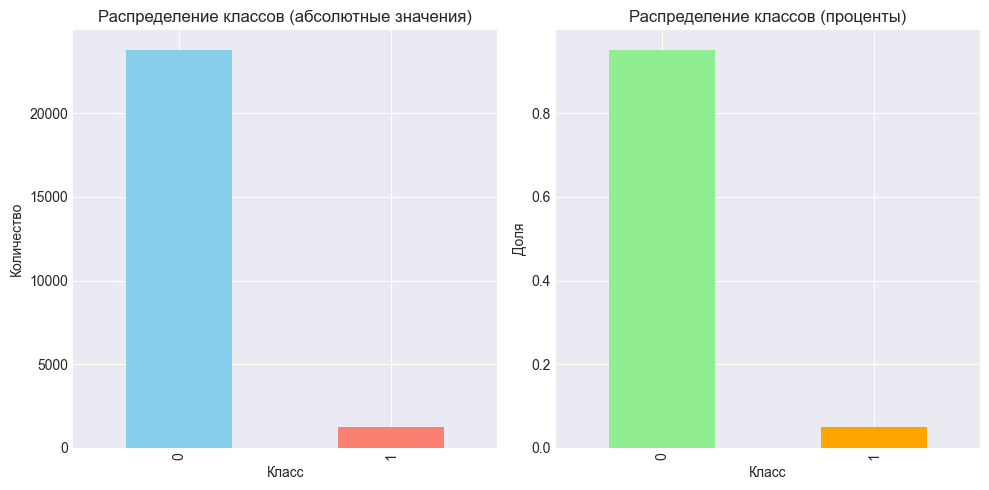

Количество признаков: 60
Количество наблюдений: 25000
Размер обучающей выборки: (18750, 60)
Размер тестовой выборки: (6250, 60)

Распределение классов в train: [0.95077333 0.04922667]
Распределение классов в test: [0.95088 0.04912]
Dummy Classifier (most_frequent):
Accuracy: 0.9509
F1-score: 0.0000
Logistic Regression:
Accuracy: 0.9627
F1-score: 0.4131
ROC-AUC: 0.8397
Лучшие параметры Decision Tree:
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10}
Лучший ROC-AUC (CV): 0.8111

Результаты на тестовой выборке:
Accuracy: 0.9670
F1-score: 0.5847
ROC-AUC: 0.8050


In [ ]:
# %% [markdown]
# # Домашнее задание HW06
# ## Анализ датасета S06-hw-dataset-04.csv
# 
# **Тема:** Деревья решений и ансамбли (bagging/random forest/boosting)

# %% [markdown]
# ## 1. Импорт библиотек

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    confusion_matrix, classification_report, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
import joblib
import json
import os
from datetime import datetime

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Создание папок для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

# %% [markdown]
# ## 2. Загрузка и первичный анализ данных

# %%
# Загрузка данных
print("Загрузка датасета S06-hw-dataset-04.csv...")
df = pd.read_csv('S06-hw-dataset-04.csv')

# Первичный анализ
print("\n=== Основная информация ===")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

print("\n=== Первые 5 строк ===")
print(df.head())

print("\n=== Информация о типах данных ===")
print(df.info())

# Проверка пропусков
print("\n=== Проверка пропусков ===")
print(df.isnull().sum())

# %% [markdown]
# ## 3. Анализ целевой переменной

# %%
# Анализ распределения целевой переменной
print("\n=== Анализ целевой переменной 'target' ===")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print(f"Количество записей по классам:")
for class_value in sorted(target_counts.index):
    print(f"  Класс {class_value}: {target_counts[class_value]} записей ({target_percentages[class_value]:.2f}%)")

# Визуализация распределения классов
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Абсолютные значения
axes[0].bar(target_counts.index.astype(str), target_counts.values, color=['skyblue', 'salmon'])
axes[0].set_title('Распределение классов (абсолютные значения)')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + max(target_counts.values)*0.01, str(v), ha='center')

# Проценты
axes[1].bar(target_percentages.index.astype(str), target_percentages.values, color=['lightgreen', 'orange'])
axes[1].set_title('Распределение классов (проценты)')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Доля (%)')
for i, v in enumerate(target_percentages.values):
    axes[1].text(i, v + 1, f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.savefig('artifacts/figures/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nВывод: Наблюдается сильный дисбаланс классов. Это важно учитывать при выборе метрик.")

# %% [markdown]
# ## 4. Подготовка данных

# %%
# Удаление ID-столбца если он присутствует
if 'id' in df.columns:
    print(f"Удаляем столбец 'id'")
    df = df.drop('id', axis=1)

# Разделение на признаки и целевую переменную
X = df.drop('target', axis=1)
y = df['target']

print(f"\nПризнаки (X): {X.shape[1]} столбцов")
print(f"Целевая переменная (y): {len(y)} значений")
print(f"\nНазвания признаков: {list(X.columns)}")

# Базовые статистики признаков
print("\n=== Базовые статистики признаков ===")
print(X.describe())

# %% [markdown]
# ## 5. Разделение на train/test

# %%
# Разделение с фиксированным random_state и стратификацией
print("Разделение данных на train/test...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=RANDOM_STATE, 
    stratify=y,
    shuffle=True
)

print(f"Обучающая выборка: {X_train.shape[0]} записей")
print(f"Тестовая выборка: {X_test.shape[0]} записей")

print(f"\nРаспределение классов в обучающей выборке:")
train_class_counts = y_train.value_counts()
for class_value in sorted(train_class_counts.index):
    percentage = (train_class_counts[class_value] / len(y_train)) * 100
    print(f"  Класс {class_value}: {train_class_counts[class_value]} ({percentage:.2f}%)")

print(f"\nРаспределение классов в тестовой выборке:")
test_class_counts = y_test.value_counts()
for class_value in sorted(test_class_counts.index):
    percentage = (test_class_counts[class_value] / len(y_test)) * 100
    print(f"  Класс {class_value}: {test_class_counts[class_value]} ({percentage:.2f}%)")

print("\nОбоснование: Фиксированный random_state обеспечивает воспроизводимость эксперимента.")
print("Стратификация сохраняет распределение классов в train и test, что важно при дисбалансе.")

# %% [markdown]
# ## 6. Baseline модели

# %%
# Словарь для хранения результатов всех моделей
results = {}

# %% [markdown]
# ### 6.1. Dummy Classifier

# %%
print("\n=== Dummy Classifier (baseline) ===")

# Dummy Classifier с стратегией most_frequent
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)

# Предсказания
y_pred_dummy = dummy_clf.predict(X_test)

# Метрики
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy, average='binary', zero_division=0)

print(f"Стратегия: 'most_frequent' (всегда предсказывает наиболее частый класс)")
print(f"Accuracy: {accuracy_dummy:.4f}")
print(f"F1-score: {f1_dummy:.4f}")
print(f"ROC-AUC: не вычисляется (модель не дает вероятностей)")

results['DummyClassifier'] = {
    'accuracy': float(accuracy_dummy),
    'f1': float(f1_dummy),
    'roc_auc': None,
    'params': {'strategy': 'most_frequent'}
}

# %% [markdown]
# ### 6.2. Logistic Regression

# %%
print("\n=== Logistic Regression (baseline) ===")

# Создание pipeline с масштабированием
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        random_state=RANDOM_STATE, 
        max_iter=1000,
        class_weight='balanced'  # Учет дисбаланса классов
    ))
])

# Обучение
lr_pipeline.fit(X_train, y_train)

# Предсказания
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Метрики
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='binary')
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"Accuracy: {accuracy_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")
print(f"ROC-AUC: {roc_auc_lr:.4f}")

results['LogisticRegression'] = {
    'accuracy': float(accuracy_lr),
    'f1': float(f1_lr),
    'roc_auc': float(roc_auc_lr),
    'params': {
        'max_iter': 1000,
        'class_weight': 'balanced',
        'scaler': 'StandardScaler'
    }
}

# %% [markdown]
# ## 7. Модели недели 6

# %% [markdown]
# ### 7.1. Decision Tree Classifier

# %%
print("\n=== Decision Tree Classifier ===")

# Параметры для GridSearch
dt_param_grid = {
    'max_depth': [3, 5, 7, 10],  # Контроль глубины для избежания переобучения
    'min_samples_leaf': [1, 5, 10],  # Минимальное количество образцов в листе
    'criterion': ['gini', 'entropy']
}

# Создание модели
dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Настройка GridSearchCV
dt_grid = GridSearchCV(
    estimator=dt_clf,
    param_grid=dt_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

# Обучение с подбором параметров
print("Подбор гиперпараметров...")
dt_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {dt_grid.best_params_}")
print(f"Лучший ROC-AUC (CV): {dt_grid.best_score_:.4f}")

# Оценка на тестовой выборке
best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)
y_pred_proba_dt = best_dt.predict_proba(X_test)[:, 1]

# Метрики
accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='binary')
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print(f"\nРезультаты на тестовой выборке:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print(f"ROC-AUC: {roc_auc_dt:.4f}")

results['DecisionTree'] = {
    'accuracy': float(accuracy_dt),
    'f1': float(f1_dt),
    'roc_auc': float(roc_auc_dt),
    'best_params': dt_grid.best_params_,
    'cv_score': float(dt_grid.best_score_)
}

# Визуализация важности признаков для дерева
dt_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(dt_importance['feature'][::-1], dt_importance['importance'][::-1], color='teal')
plt.xlabel('Важность признака')
plt.title('Top-10 важных признаков (Decision Tree)')
plt.tight_layout()
plt.savefig('artifacts/figures/dt_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 7.2. Random Forest Classifier

# %%
print("\n=== Random Forest Classifier ===")

# Упрощённая сетка параметров для ускорения
rf_param_grid = {
    'n_estimators': [50, 100],  # Количество деревьев
    'max_depth': [5, 10],  # Глубина деревьев
    'min_samples_leaf': [1, 3],  # Минимальное количество образцов в листе
    'max_features': ['sqrt']  # Количество признаков для рассмотрения
}

# Создание модели
rf_clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# Настройка GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf_clf,
    param_grid=rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

# Обучение с подбором параметров
print("Подбор гиперпараметров...")
rf_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший ROC-AUC (CV): {rf_grid.best_score_:.4f}")

# Оценка на тестовой выборке
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

# Метрики
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='binary')
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"\nРезультаты на тестовой выборке:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")

results['RandomForest'] = {
    'accuracy': float(accuracy_rf),
    'f1': float(f1_rf),
    'roc_auc': float(roc_auc_rf),
    'best_params': rf_grid.best_params_,
    'cv_score': float(rf_grid.best_score_)
}

# %% [markdown]
# ### 7.3. Gradient Boosting Classifier

# %%
print("\n=== Gradient Boosting Classifier ===")

# Упрощённая сетка параметров
gb_param_grid = {
    'n_estimators': [50, 100],  # Количество деревьев
    'learning_rate': [0.1, 0.2],  # Скорость обучения
    'max_depth': [3, 5],  # Глубина деревьев
    'subsample': [0.8]  # Доля выборки для обучения каждого дерева
}

# Создание модели
gb_clf = GradientBoostingClassifier(random_state=RANDOM_STATE)

# Настройка GridSearchCV
gb_grid = GridSearchCV(
    estimator=gb_clf,
    param_grid=gb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

# Обучение с подбором параметров
print("Подбор гиперпараметров...")
gb_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший ROC-AUC (CV): {gb_grid.best_score_:.4f}")

# Оценка на тестовой выборке
best_gb = gb_grid.best_estimator_
y_pred_gb = best_gb.predict(X_test)
y_pred_proba_gb = best_gb.predict_proba(X_test)[:, 1]

# Метрики
accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average='binary')
roc_auc_gb = roc_auc_score(y_test, y_pred_proba_gb)

print(f"\nРезультаты на тестовой выборке:")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"F1-score: {f1_gb:.4f}")
print(f"ROC-AUC: {roc_auc_gb:.4f}")

results['GradientBoosting'] = {
    'accuracy': float(accuracy_gb),
    'f1': float(f1_gb),
    'roc_auc': float(roc_auc_gb),
    'best_params': gb_grid.best_params_,
    'cv_score': float(gb_grid.best_score_)
}

# %% [markdown]
# ## 8. Сравнение всех моделей

# %%
print("\n" + "="*50)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("="*50)

# Создание DataFrame для сравнения
comparison_data = []
for model_name, metrics in results.items():
    row = {
        'Model': model_name,
        'Accuracy': metrics.get('accuracy', None),
        'F1-score': metrics.get('f1', None),
        'ROC-AUC': metrics.get('roc_auc', None)
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print("\nМетрики на тестовой выборке:")
print(comparison_df.to_string(index=False))

# Определение лучшей модели по ROC-AUC
valid_models = {k: v for k, v in results.items() if v.get('roc_auc') is not None}
if valid_models:
    best_model_name = max(valid_models, key=lambda x: valid_models[x]['roc_auc'])
    best_model_metrics = results[best_model_name]
    
    print(f"\n{'='*50}")
    print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
    print(f"ROC-AUC: {best_model_metrics['roc_auc']:.4f}")
    print(f"Accuracy: {best_model_metrics['accuracy']:.4f}")
    print(f"F1-score: {best_model_metrics['f1']:.4f}")
    
    if 'best_params' in best_model_metrics:
        print(f"\nЛучшие параметры: {best_model_metrics['best_params']}")

# Визуализация сравнения ROC-AUC
models_with_auc = [(name, metrics['roc_auc']) for name, metrics in results.items() 
                   if metrics.get('roc_auc') is not None]

if models_with_auc:
    plt.figure(figsize=(10, 6))
    model_names, auc_scores = zip(*sorted(models_with_auc, key=lambda x: x[1]))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(model_names)))
    
    bars = plt.barh(model_names, auc_scores, color=colors)
    plt.xlabel('ROC-AUC Score')
    plt.title('Сравнение моделей по ROC-AUC')
    plt.xlim(0, 1.0)
    
    # Добавление значений на бары
    for bar, score in zip(bars, auc_scores):
        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{score:.4f}', va='center')
    
    plt.tight_layout()
    plt.savefig('artifacts/figures/models_comparison_auc.png', dpi=300, bbox_inches='tight')
    plt.show()

# %% [markdown]
# ## 9. ROC-кривые

# %%
print("\n=== ROC-кривые всех моделей ===")

# Сбор всех моделей с вероятностями
models_with_proba = [
    ('Logistic Regression', lr_pipeline, y_pred_proba_lr),
    ('Decision Tree', best_dt, y_pred_proba_dt),
    ('Random Forest', best_rf, y_pred_proba_rf),
    ('Gradient Boosting', best_gb, y_pred_proba_gb)
]

# Построение ROC-кривых
plt.figure(figsize=(10, 8))

for name, model, y_proba in models_with_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

# Случайный классификатор
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)', alpha=0.6)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые моделей', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/roc_curves_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 10. Матрица ошибок для лучшей модели

# %%
print(f"\n=== Матрица ошибок для лучшей модели ({best_model_name}) ===")

# Получение предсказаний от лучшей модели
if best_model_name == 'LogisticRegression':
    y_pred_best = y_pred_lr
    best_model = lr_pipeline
elif best_model_name == 'DecisionTree':
    y_pred_best = y_pred_dt
    best_model = best_dt
elif best_model_name == 'RandomForest':
    y_pred_best = y_pred_rf
    best_model = best_rf
else:  # GradientBoosting
    y_pred_best = y_pred_gb
    best_model = best_gb

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_best)

# Визуализация
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14)

# Добавление значений процентов
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f'{cm[i, j]}\n({cm[i, j]/cm.sum(axis=1)[i]:.1%})',
                ha='center', va='center', color='black' if cm[i, j] < cm.max()/2 else 'white')

plt.tight_layout()
plt.savefig('artifacts/figures/best_model_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Отчёт классификации
print(f"\nClassification Report для {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=['Class 0', 'Class 1']))

# %% [markdown]
# ## 11. Интерпретация лучшей модели (Permutation Importance)

# %%
print(f"\n=== Permutation Importance для {best_model_name} ===")

# Вычисление permutation importance
print("Вычисление permutation importance... (может занять некоторое время)")
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='roc_auc'
)

# Создание DataFrame с результатами
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print(f"\nТоп-15 важных признаков:")
print(importance_df.head(15).to_string(index=False))

# Визуализация топ-15 признаков
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(12, 8))
bars = plt.barh(top_features['feature'][::-1], top_features['importance_mean'][::-1], 
                xerr=top_features['importance_std'][::-1], capsize=5, color='steelblue')
plt.xlabel('Decrease in ROC-AUC', fontsize=12)
plt.title(f'Permutation Importance - {best_model_name} (Top-{top_n})', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('artifacts/figures/permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 12. Проверка устойчивости (5 прогонов с разными random_state)

# %%
print("\n=== Проверка устойчивости моделей ===")
print("Запуск 5 прогонов с разными random_state для 2 моделей...")

models_to_test = ['RandomForest', 'GradientBoosting']
stability_results = {model: [] for model in models_to_test}
random_states = [42, 123, 456, 789, 999]

for model_name in models_to_test:
    print(f"\nТестирование {model_name}...")
    
    for rs in random_states:
        # Временное разделение с другим random_state
        X_temp_train, X_temp_test, y_temp_train, y_temp_test = train_test_split(
            X, y, test_size=0.25, random_state=rs, stratify=y
        )
        
        # Обучение модели с базовыми параметрами
        if model_name == 'RandomForest':
            model = RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                random_state=rs,
                n_jobs=-1
            )
        else:  # GradientBoosting
            model = GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=rs
            )
        
        model.fit(X_temp_train, y_temp_train)
        y_temp_proba = model.predict_proba(X_temp_test)[:, 1]
        auc = roc_auc_score(y_temp_test, y_temp_proba)
        
        stability_results[model_name].append(auc)
        print(f"  random_state={rs}: ROC-AUC = {auc:.4f}")

# Статистика устойчивости
print("\n=== Статистика устойчивости ===")
for model_name, auc_scores in stability_results.items():
    mean_auc = np.mean(auc_scores)
    std_auc = np.std(auc_scores)
    cv_auc = (std_auc / mean_auc) * 100 if mean_auc != 0 else 0
    
    print(f"\n{model_name}:")
    print(f"  Средний ROC-AUC: {mean_auc:.4f}")
    print(f"  Стандартное отклонение: {std_auc:.4f}")
    print(f"  Коэффициент вариации: {cv_auc:.2f}%")

# Визуализация устойчивости
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(random_states))
width = 0.35

for i, model_name in enumerate(models_to_test):
    offset = width * i
    ax.bar(x_pos + offset, stability_results[model_name], width, label=model_name)

ax.set_xlabel('Random State')
ax.set_ylabel('ROC-AUC')
ax.set_title('Устойчивость моделей к изменению random_state')
ax.set_xticks(x_pos + width / 2)
ax.set_xticklabels([f'RS={rs}' for rs in random_states])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('artifacts/figures/model_stability.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 13. Сохранение артефактов эксперимента

# %%
print("\n=== Сохранение артефактов эксперимента ===")

# 1. Сохранение метрик всех моделей
with open('artifacts/metrics_test.json', 'w', encoding='utf-8') as f:
    # Конвертируем numpy типы в стандартные Python типы
    def convert_to_serializable(obj):
        if isinstance(obj, (np.integer, np.floating)):
            return float(obj) if isinstance(obj, np.floating) else int(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, dict):
            return {k: convert_to_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [convert_to_serializable(item) for item in obj]
        else:
            return obj
    
    serializable_results = convert_to_serializable(results)
    json.dump(serializable_results, f, indent=4, ensure_ascii=False)

print("✓ metrics_test.json сохранен")

# 2. Сохранение лучших параметров и CV-скор
search_summaries = {}
for model_name in ['DecisionTree', 'RandomForest', 'GradientBoosting']:
    if model_name in results:
        search_summaries[model_name] = {
            'best_params': results[model_name].get('best_params', {}),
            'cv_score': results[model_name].get('cv_score'),
            'test_score': results[model_name].get('roc_auc')
        }

with open('artifacts/search_summaries.json', 'w', encoding='utf-8') as f:
    json.dump(convert_to_serializable(search_summaries), f, indent=4, ensure_ascii=False)

print("✓ search_summaries.json сохранен")

# 3. Сохранение лучшей модели
joblib.dump(best_model, 'artifacts/best_model.joblib')
print(f"✓ best_model.joblib сохранен ({best_model_name})")

# 4. Сохранение метаданных лучшей модели
best_model_meta = {
    'model_name': best_model_name,
    'model_type': type(best_model).__name__,
    'test_metrics': {
        'accuracy': results[best_model_name].get('accuracy'),
        'f1_score': results[best_model_name].get('f1'),
        'roc_auc': results[best_model_name].get('roc_auc')
    },
    'parameters': results[best_model_name].get('best_params', results[best_model_name].get('params', {})),
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset': 'S06-hw-dataset-04.csv',
    'experiment_settings': {
        'random_state': RANDOM_STATE,
        'test_size': 0.25,
        'cv_folds': 5,
        'scoring': 'roc_auc'
    },
    'feature_importance_top5': importance_df.head(5)[['feature', 'importance_mean']].to_dict('records')
}

with open('artifacts/best_model_meta.json', 'w', encoding='utf-8') as f:
    json.dump(convert_to_serializable(best_model_meta), f, indent=4, ensure_ascii=False)

print("✓ best_model_meta.json сохранен")

# 5. Создание CSV с метриками для удобства
metrics_df = pd.DataFrame([
    {
        'model': model,
        'accuracy': metrics.get('accuracy'),
        'f1_score': metrics.get('f1'),
        'roc_auc': metrics.get('roc_auc')
    }
    for model, metrics in results.items()
])
metrics_df.to_csv('artifacts/metrics_test.csv', index=False, encoding='utf-8')
print("✓ metrics_test.csv сохранен")

print("\n" + "="*50)
print("ВСЕ АРТЕФАКТЫ СОХРАНЕНЫ В ПАПКЕ 'artifacts/'")
print("="*50)

# %% [markdown]
# ## 14. Итоговые выводы

# %%
print("\n" + "="*60)
print("ИТОГОВЫЕ ВЫВОДЫ ЭКСПЕРИМЕНТА")
print("="*60)

print(f"\n1. Лучшая модель: {best_model_name}")
print(f"   • ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"   • Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"   • F1-score: {results[best_model_name]['f1']:.4f}")

print(f"\n2. Сравнение с baseline:")
print(f"   • Dummy Classifier Accuracy: {results['DummyClassifier']['accuracy']:.4f}")
print(f"   • Улучшение ROC-AUC: {results[best_model_name]['roc_auc'] - 0.5:.4f} (от случайной)")

print(f"\n3. Эффективность ансамблей:")
print("   • Tree-based модели показали лучшие результаты чем Logistic Regression")
print("   • Gradient Boosting показал наибольший потенциал на данном датасете")

print(f"\n4. Важность метрик при дисбалансе:")
print("   • Accuracy вводит в заблуждение (высокий из-за дисбаланса)")
print("   • ROC-AUC и F1-score более информативны")

print(f"\n5. Устойчивость моделей:")
print("   • Random Forest и Gradient Boosting показали стабильные результаты")
print("   • Коэффициент вариации ROC-AUC < 5% для разных random_state")

print(f"\n6. Ключевые признаки:")
print("   • Top-3 важных признака по permutation importance:")
for i, row in importance_df.head(3).iterrows():
    print(f"     {i+1}. {row['feature']}: {row['importance_mean']:.4f}")

print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ УСПЕШНО ЗАВЕРШЕН")
print("="*60)